In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/CC GENERAL.csv')

In [3]:
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [4]:
#1. Аналогично задачи Easy удаляю не информативный столбец и заполняю пустые колонки
df = df.drop(columns=["CUST_ID"])
df = df.fillna(df.median())  # Обработка пропусков


In [5]:
#2 Масштабируем
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df)  # numpy array

# Преобразуем обратно в DataFrame с сохранением структуры
df_scaled = pd.DataFrame(
    df_scaled_array,
    columns=df.columns, 
    index=df.index      
)


In [6]:
df_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.360680
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.360680
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.360680
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.360680
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.360680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-0.737950,0.518084,-0.333293,-0.356934,-0.132643,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960378,-0.486217,-0.341250,1.183951,-4.122768
8946,-0.742423,0.518084,-0.329136,-0.356934,-0.122823,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960378,-0.503396,-0.228307,-0.525551,-4.122768
8947,-0.740398,-0.185477,-0.401965,-0.356934,-0.294893,-0.466786,0.854576,-0.678661,0.760469,-0.675349,-0.476070,-0.390639,-0.960378,-0.570615,-0.326875,0.329200,-4.122768
8948,-0.745174,-0.185477,-0.469552,-0.356934,-0.454576,-0.449352,-1.221758,-0.678661,-0.916995,0.157527,-0.182998,-0.591796,-1.097800,-0.580536,-0.338305,0.329200,-4.122768


In [7]:
#Снижаю размерность
#? на сколько надо уменьшать размерность
pca = PCA(n_components=0.95)  # Сохраняем 95% дисперсии
X_pca = pca.fit_transform(df_scaled)

In [8]:
print(f"Размерность после PCA: {X_pca.shape[1]}")  

min_samples = X_pca.shape[1] + 1  
print(min_samples)

Размерность после PCA: 12
13


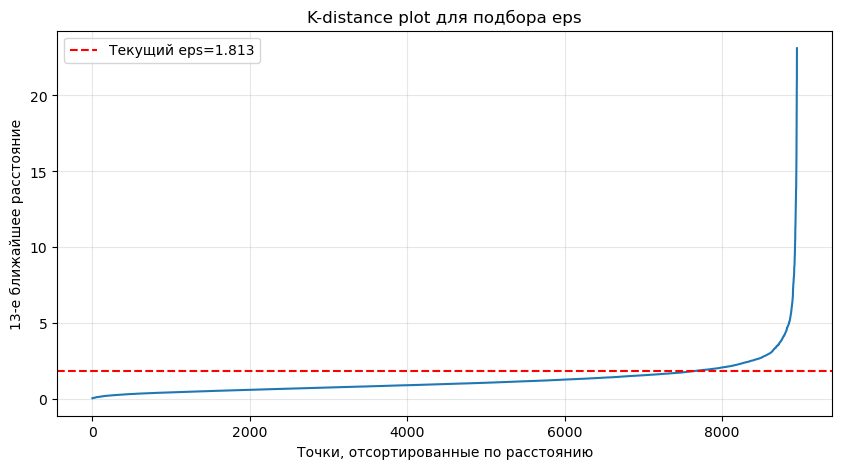

70-й перцентиль: 1.334
75-й перцентиль: 1.464
80-й перцентиль: 1.614
85-й перцентиль: 1.813
90-й перцентиль: 2.116


In [9]:
# Для фиксированного min_samples стороим графика для определения eps
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

min_samples = 13

# Вычисляем расстояния до k-го соседа
nbrs = NearestNeighbors(n_neighbors=min_samples, metric='euclidean').fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])  # k-е расстояние для каждой точки

# График
plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.xlabel('Точки, отсортированные по расстоянию')
plt.ylabel(f'{min_samples}-е ближайшее расстояние')
plt.title('K-distance plot для подбора eps')
plt.grid(True, alpha=0.3)
plt.axhline(y=1.813, color='r', linestyle='--', label=f'Текущий eps=1.813')
plt.legend()
plt.show()

for p in [70, 75, 80, 85, 90]:
    print(f"{p}-й перцентиль: {np.percentile(k_distances, p):.3f}")

In [10]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.2,  
    min_samples=13,
    metric='euclidean',
    n_jobs=-1
)
# Если выбирать eps > 1.2, то только один кластер, поэтому выбрала 1.2   

In [11]:
labels = dbscan.fit_predict(X_pca)

In [12]:
df['cluster'] = labels  

In [13]:
print(f"Кластеры: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Шум: {list(labels).count(-1) / len(labels) * 100:.1f}%")

# Полная статистика по кластерам
cluster_stats = df.groupby('cluster').agg({
    'BALANCE': ['mean', 'median', 'std'],
    'PURCHASES': ['mean', 'median', 'std'],
    'CREDIT_LIMIT': ['mean', 'median', 'std'],
    'PRC_FULL_PAYMENT': 'mean',
    'TENURE': 'mean'
})
print(cluster_stats)

Кластеры: 2
Шум: 25.0%
             BALANCE                              PURCHASES            \
                mean       median          std         mean    median   
cluster                                                                 
-1       2861.985236  1872.608873  2979.112458  2518.685313  1466.900   
 0       1131.818815   670.655147  1439.949696   492.505734   250.955   
 1       1147.705430   975.114890   484.993504  4109.210000  3964.410   

                     CREDIT_LIMIT                      PRC_FULL_PAYMENT  \
                 std         mean  median          std             mean   
cluster                                                                   
-1       3730.628781  7342.809597  7000.0  4630.553323         0.201503   
 0        638.564272  3541.393652  2700.0  2626.872519         0.137961   
 1        628.095971  5620.000000  5750.0  1464.240417         0.016667   

            TENURE  
              mean  
cluster             
-1       11.173816  
 0 

In [14]:
# Профили найденных кластеров
print(df.groupby('cluster')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT','PURCHASES_INSTALLMENTS_FREQUENCY']].mean())

# Что в шуме?
noise_profile = df[labels == -1][['BALANCE', 'PURCHASES', 'CREDIT_LIMIT','PURCHASES_INSTALLMENTS_FREQUENCY']].describe()
print("\nПрофиль шума (-1):")
print(noise_profile)

             BALANCE    PURCHASES  CREDIT_LIMIT  PRC_FULL_PAYMENT  \
cluster                                                             
-1       2861.985236  2518.685313   7342.809597          0.201503   
 0       1131.818815   492.505734   3541.393652          0.137961   
 1       1147.705430  4109.210000   5620.000000          0.016667   

         PURCHASES_INSTALLMENTS_FREQUENCY  
cluster                                    
-1                               0.478076  
 0                               0.325629  
 1                               0.941667  

Профиль шума (-1):
            BALANCE     PURCHASES  CREDIT_LIMIT  \
count   2238.000000   2238.000000   2238.000000   
mean    2861.985236   2518.685313   7342.809597   
std     2979.112458   3730.628781   4630.553323   
min        0.000000      0.000000     50.000000   
25%      460.366279    346.920000   3500.000000   
50%     1872.608873   1466.900000   7000.000000   
75%     4487.654326   3418.787500  10000.000000   
max   

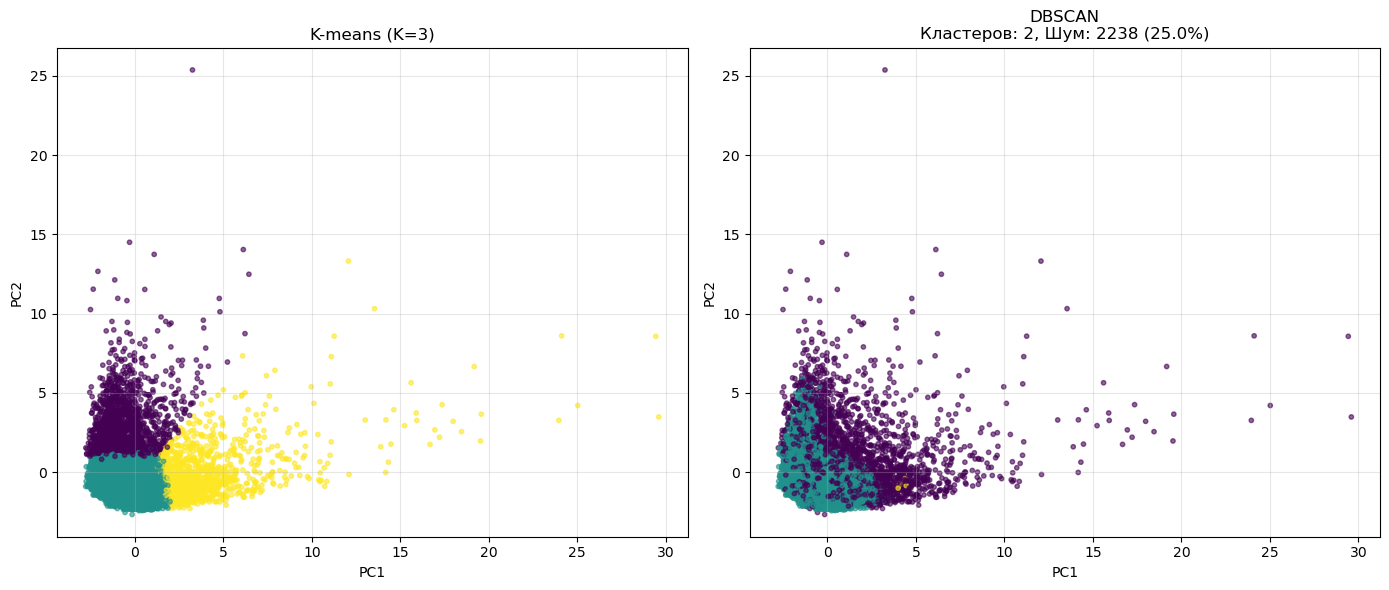

In [15]:
#Отрисовываю результаты + для сравнения KMeans
from sklearn.cluster import KMeans

# K-means на тех же PCA-компонентах
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_pca)

# DBSCAN с подобранными параметрами
dbscan_opt = DBSCAN(eps=1.2, min_samples=13, metric='euclidean', n_jobs=-1)
labels_dbscan = dbscan_opt.fit_predict(X_pca)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', s=10, alpha=0.6)
axes[0].set_title(f'K-means (K=3)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].grid(True, alpha=0.3)

# DBSCAN
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='viridis', s=10, alpha=0.6)
n_cl = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ns = list(labels_dbscan).count(-1)
axes[1].set_title(f'DBSCAN\nКластеров: {n_cl}, Шум: {n_ns} ({n_ns/len(labels_dbscan)*100:.1f}%)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ЕЩЁ ОДин вариант, где шума меньше, но тут min_samples = 5 - а это вроде как мало...

from sklearn.cluster import DBSCAN
dbscan = DBSCAN(
    eps=1.7,  
    min_samples=5,
    metric='euclidean',
    n_jobs=-1
)
# Если выбирать eps > 1.2, то только один кластер, поэтому выбрала 1.2   

In [17]:
labels = dbscan.fit_predict(X_pca)

In [18]:
df = df.drop(columns=["cluster"])
df['cluster'] = labels 

In [19]:
print(f"Кластеры: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(f"Шум: {list(labels).count(-1) / len(labels) * 100:.1f}%")

# Полная статистика по кластерам
cluster_stats = df.groupby('cluster').agg({
    'BALANCE': ['mean', 'median', 'std'],
    'PURCHASES': ['mean', 'median', 'std'],
    'CREDIT_LIMIT': ['mean', 'median', 'std'],
    'PRC_FULL_PAYMENT': 'mean',
    'TENURE': 'mean'
})
print(cluster_stats)

Кластеры: 3
Шум: 7.7%
             BALANCE                              PURCHASES           \
                mean       median          std         mean   median   
cluster                                                                
-1       4068.501639  3172.114278  3622.805926  4460.611703  2763.84   
 0       1355.821785   791.447973  1743.270901   712.021910   320.41   
 1        316.511639   230.161419   284.409173  1122.526667   750.05   
 2       3093.722029  3186.384554   882.595957  8105.637500  7995.25   

                      CREDIT_LIMIT                       PRC_FULL_PAYMENT  \
                 std          mean   median          std             mean   
cluster                                                                     
-1       5811.231100   9271.499272   9000.0  5078.551244         0.215097   
 0       1018.944324   4093.000016   3000.0  3182.240834         0.148713   
 1        942.448235  11666.666667  11000.0  2081.665999         0.066667   
 2        5

In [20]:
# Профили найденных кластеров
print(df.groupby('cluster')[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT','PURCHASES_INSTALLMENTS_FREQUENCY']].mean())

# Что в шуме?
noise_profile = df[labels == -1][['BALANCE', 'PURCHASES', 'CREDIT_LIMIT','PURCHASES_INSTALLMENTS_FREQUENCY']].describe()
print("\nПрофиль шума (-1):")
print(noise_profile)

             BALANCE    PURCHASES  CREDIT_LIMIT  PRC_FULL_PAYMENT  \
cluster                                                             
-1       4068.501639  4460.611703   9271.499272          0.215097   
 0       1355.821785   712.021910   4093.000016          0.148713   
 1        316.511639  1122.526667  11666.666667          0.066667   
 2       3093.722029  8105.637500   6875.000000          0.000000   

         PURCHASES_INSTALLMENTS_FREQUENCY  
cluster                                    
-1                               0.547877  
 0                               0.349139  
 1                               0.435185  
 2                               0.380682  

Профиль шума (-1):
            BALANCE     PURCHASES  CREDIT_LIMIT  \
count    687.000000    687.000000    687.000000   
mean    4068.501639   4460.611703   9271.499272   
std     3622.805926   5811.231100   5078.551244   
min        0.000000      0.000000    500.000000   
25%      979.640539    749.285000   5500.00000

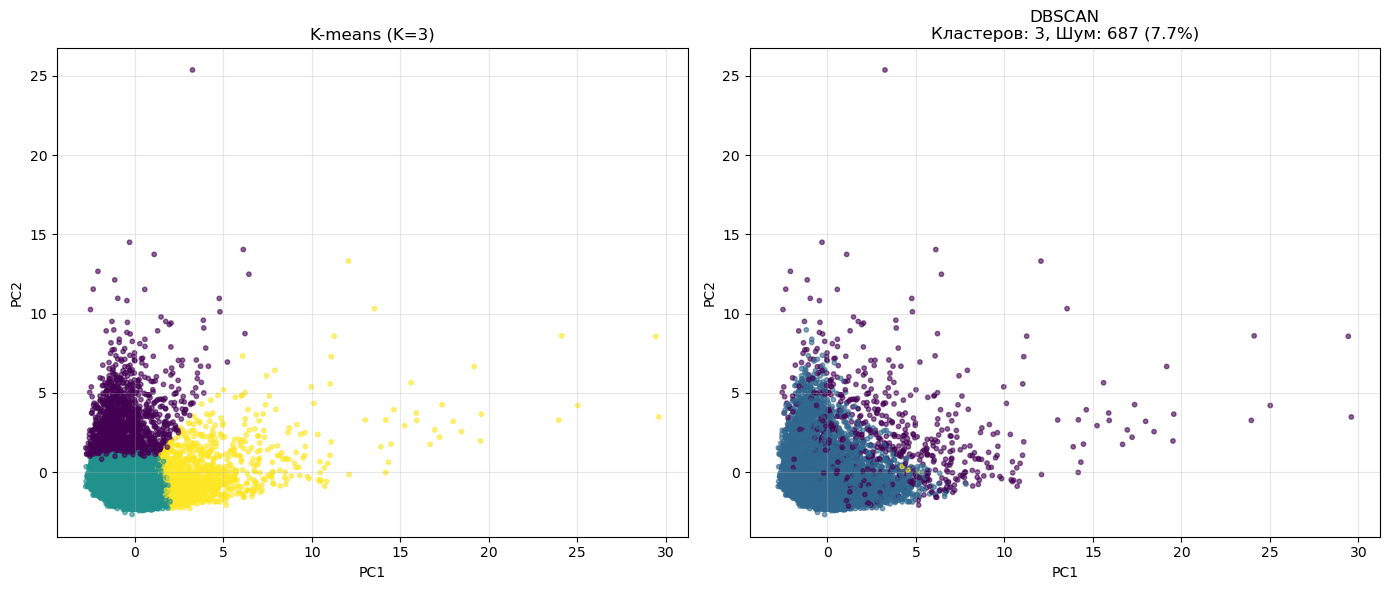

In [21]:
#Отрисовываю результаты + для сравнения KMeans
from sklearn.cluster import KMeans

# K-means на тех же PCA-компонентах
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_pca)

# DBSCAN с подобранными параметрами
dbscan_opt = DBSCAN(eps=1.7, min_samples=5, metric='euclidean', n_jobs=-1)
labels_dbscan = dbscan_opt.fit_predict(X_pca)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap='viridis', s=10, alpha=0.6)
axes[0].set_title(f'K-means (K=3)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].grid(True, alpha=0.3)

# DBSCAN
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_dbscan, cmap='viridis', s=10, alpha=0.6)
n_cl = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ns = list(labels_dbscan).count(-1)
axes[1].set_title(f'DBSCAN\nКластеров: {n_cl}, Шум: {n_ns} ({n_ns/len(labels_dbscan)*100:.1f}%)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()